# 05 — Merchandise product mix and negative-value impact

Answers questions **8** and **9** using the same preparation as notebooks 01–04.
SQL Server Raw stays the source of truth. Fresh kernel (reloads from SQL).

Product grouping key is **StockCode**. Description is supporting text only (it can drift).
Negative merchandise value is signed and is **not** a confirmed refund rate or churn event.

## 0. Setup and reload Raw (SELECT only)

In [1]:
from datetime import datetime
from decimal import Decimal, ROUND_HALF_UP
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyodbc

PROJECT = Path("..").resolve()
if not (PROJECT / "scripts").exists():
    PROJECT = Path(".").resolve()
TABLES = PROJECT / "outputs" / "tables"
FIGURES = PROJECT / "outputs" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)


def unique_output_path(path: Path) -> Path:
    # If the target exists, write a timestamped file instead of overwriting.
    if not path.exists():
        return path
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{stamp}{path.suffix}")


server = r".\MSSQLSERVER02"
database = "RetailAnalytics"
driver = "ODBC Driver 18 for SQL Server"
connection_string = (
    f"DRIVER={{{driver}}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

read_sql = (
    "SELECT raw_row_id, InvoiceNo, StockCode, Description, Quantity, "
    "InvoiceDate, UnitPrice, CustomerID, Country, source_file, loaded_at "
    "FROM raw.online_retail;"
)

connection = pyodbc.connect(connection_string)
try:
    df_raw = pd.read_sql(read_sql, connection)
finally:
    connection.close()

df = df_raw.copy()
EXPECTED_ROWS = 541_909
assert len(df) == EXPECTED_ROWS
print("Loaded", len(df), "rows")

C:\Users\Admin\AppData\Local\Temp\ipykernel_37668\2765357772.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql(read_sql, connection)


Loaded 541909 rows


## 1. Same preparation as notebooks 01–04

In [2]:
def penny(x) -> Decimal:
    return Decimal(str(float(x))).quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)


def penny_sum(series: pd.Series) -> Decimal:
    return penny(float(series.sum())) if len(series) else Decimal("0.00")


for col in ["InvoiceNo", "StockCode", "CustomerID", "Country"]:
    df[col] = df[col].astype("string")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
desc = df["Description"].astype("string").str.strip()
df["Description_clean"] = desc.mask(desc.eq(""), pd.NA)
df["UnitPrice"] = df["UnitPrice"].astype("float64")
df["line_value"] = df["Quantity"] * df["UnitPrice"]
df["is_c_prefix_invoice"] = df["InvoiceNo"].str.upper().str.startswith("C", na=False)

STOCKCODE_GROUP = {
    "POST": "postage_carriage",
    "DOT": "postage_carriage",
    "C2": "postage_carriage",
    "AMAZONFEE": "fees_commission",
    "CRUK": "fees_commission",
    "BANK CHARGES": "fees_commission",
    "D": "discount",
    "M": "manual_unresolved",
    "S": "samples",
    "B": "bad_debt_adjustment",
}
df["code_group"] = df["StockCode"].map(STOCKCODE_GROUP).astype("string")
df["code_group"] = df["code_group"].fillna("merchandise_candidate")
adjust_bad_debt = df["Description"].astype("string").str.contains(
    "Adjust bad debt", case=False, na=False
)
df.loc[adjust_bad_debt, "code_group"] = "bad_debt_adjustment"

BUSINESS_COLS = [
    "InvoiceNo", "StockCode", "Description", "Quantity",
    "InvoiceDate", "UnitPrice", "CustomerID", "Country",
]
g = df.groupby(BUSINESS_COLS, dropna=False, sort=False)
df["duplicate_group_size"] = g["raw_row_id"].transform("size")
df["duplicate_row_number"] = g["raw_row_id"].rank(method="first")
df["is_duplicate_extra"] = (df["duplicate_group_size"] > 1) & (df["duplicate_row_number"] > 1)

df["invoice_month"] = df["InvoiceDate"].dt.to_period("M")
max_ts = df["InvoiceDate"].max()
partial_month = max_ts.to_period("M")
df["is_final_partial_month"] = df["invoice_month"] == partial_month

is_merch = df["code_group"] == "merchandise_candidate"
mask_sale = (
    is_merch & (df["Quantity"] > 0) & (df["UnitPrice"] > 0) & ~df["is_c_prefix_invoice"]
)
mask_neg = is_merch & (df["Quantity"] < 0) & (df["UnitPrice"] > 0)
keep = ~df["is_duplicate_extra"]

NB01_GROSS = Decimal("10272121.42")
NB01_NEG = Decimal("-478724.18")
NB01_NET = penny(NB01_GROSS + NB01_NEG)
assert penny_sum(df.loc[mask_sale, "line_value"]) == NB01_GROSS
assert penny_sum(df.loc[mask_neg, "line_value"]) == NB01_NEG
assert penny(float(df.loc[mask_sale | mask_neg, "line_value"].sum())) == NB01_NET
print("Gross / signed neg / net:", NB01_GROSS, NB01_NEG, NB01_NET)
print(df["code_group"].value_counts())

Gross / signed neg / net: 10272121.42 -478724.18 9793397.24
code_group
merchandise_candidate    538998
postage_carriage           2110
manual_unresolved           571
fees_commission              87
discount                     77
samples                      63
bad_debt_adjustment           3
Name: count, dtype: Int64


## 2. Question 8 — Product-level summary

`StockCode` is the grouping key. `representative_description` is the most frequent non-blank cleaned Description; frequency ties are broken alphabetically. Original Description is not overwritten.

StockCodes with only negative merchandise lines are kept.

In [3]:
sale = df.loc[mask_sale].copy()
neg = df.loc[mask_neg].copy()

# Representative description from merchandise-candidate lines with a cleaned description.
desc_src = df.loc[is_merch & df["Description_clean"].notna(), ["StockCode", "Description_clean"]]
desc_freq = (
    desc_src.groupby(["StockCode", "Description_clean"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values(["StockCode", "n", "Description_clean"], ascending=[True, False, True])
)
rep_desc = desc_freq.groupby("StockCode", as_index=False).first()[
    ["StockCode", "Description_clean"]
].rename(columns={"Description_clean": "representative_description"})

pos = sale.groupby("StockCode", dropna=False).agg(
    gross_merchandise_sales=("line_value", "sum"),
    positive_units=("Quantity", "sum"),
    positive_sale_invoices=("InvoiceNo", "nunique"),
    identified_purchasing_customers=("CustomerID", "nunique"),
    first_observed_positive_sale=("InvoiceDate", "min"),
    last_observed_positive_sale=("InvoiceDate", "max"),
)
neg_p = neg.groupby("StockCode", dropna=False)["line_value"].sum().rename(
    "negative_merchandise_value"
)

product = pos.join(neg_p, how="outer").reset_index()
product = product.merge(rep_desc, on="StockCode", how="left")
product["gross_merchandise_sales"] = product["gross_merchandise_sales"].fillna(0.0)
product["negative_merchandise_value"] = product["negative_merchandise_value"].fillna(0.0)
product["positive_units"] = product["positive_units"].fillna(0.0)
product["positive_sale_invoices"] = product["positive_sale_invoices"].fillna(0).astype(int)
product["identified_purchasing_customers"] = (
    product["identified_purchasing_customers"].fillna(0).astype(int)
)
product["net_merchandise_value"] = (
    product["gross_merchandise_sales"] + product["negative_merchandise_value"]
)
product["gross_sales_rank"] = product["gross_merchandise_sales"].rank(
    method="min", ascending=False
)
product["units_rank"] = product["positive_units"].rank(method="min", ascending=False)

assert penny_sum(product["gross_merchandise_sales"]) == NB01_GROSS
assert penny_sum(product["negative_merchandise_value"]) == NB01_NEG
assert penny_sum(product["net_merchandise_value"]) == NB01_NET
print("Distinct merchandise StockCodes:", len(product))
print("StockCodes with no positive sales:", int((product["gross_merchandise_sales"] == 0).sum()))

Distinct merchandise StockCodes: 3928
StockCodes with no positive sales: 14


In [4]:
total_gross = float(product["gross_merchandise_sales"].sum())
total_net = float(product["net_merchandise_value"].sum())
product["gross_share"] = product["gross_merchandise_sales"] / total_gross
hhi = float((product["gross_share"] ** 2).sum())

top10g = product.nsmallest(10, "gross_sales_rank")
top10u = product.nsmallest(10, "units_rank")
top20g = product.nsmallest(20, "gross_sales_rank")
top10n = product.sort_values(
    ["net_merchandise_value", "StockCode"], ascending=[False, True]
).head(10)

print("HHI (sum of squared gross-sales shares, 0-1 scale):", hhi)
print("Top 10 gross-sales share %:", 100 * top10g["gross_merchandise_sales"].sum() / total_gross)
print("Top 20 gross-sales share %:", 100 * top20g["gross_merchandise_sales"].sum() / total_gross)
print("Top 10 net-value share %:", 100 * top10n["net_merchandise_value"].sum() / total_net)
print("\nTop 10 by gross sales:")
print(top10g[["StockCode", "representative_description", "gross_merchandise_sales",
              "positive_units", "gross_sales_rank"]].to_string(index=False))
print("\nTop 10 by positive units:")
print(top10u[["StockCode", "representative_description", "positive_units",
              "gross_merchandise_sales", "units_rank"]].to_string(index=False))

HHI (sum of squared gross-sales shares, 0-1 scale): 0.002119067895002625
Top 10 gross-sales share %: 9.425009402948136
Top 20 gross-sales share %: 13.51973845334869
Top 10 net-value share %: 8.154686674951616

Top 10 by gross sales:
StockCode         representative_description  gross_merchandise_sales  positive_units  gross_sales_rank
    22423           REGENCY CAKESTAND 3 TIER                174484.74         13879.0               1.0
    23843        PAPER CRAFT , LITTLE BIRDIE                168469.60         80995.0               2.0
   85123A WHITE HANGING HEART T-LIGHT HOLDER                104518.80         37660.0               3.0
    47566                      PARTY BUNTING                 99504.33         18295.0               4.0
   85099B            JUMBO BAG RED RETROSPOT                 94340.05         48474.0               5.0
    23166     MEDIUM CERAMIC TOP STORAGE JAR                 81700.92         78033.0               6.0
    23084                 RABBIT NIGHT 

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\top10_products_gross.png


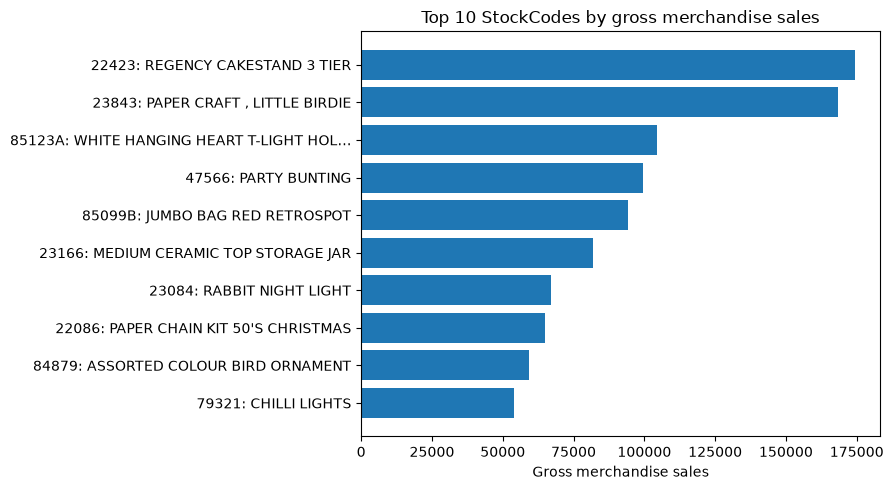

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\top10_products_units.png


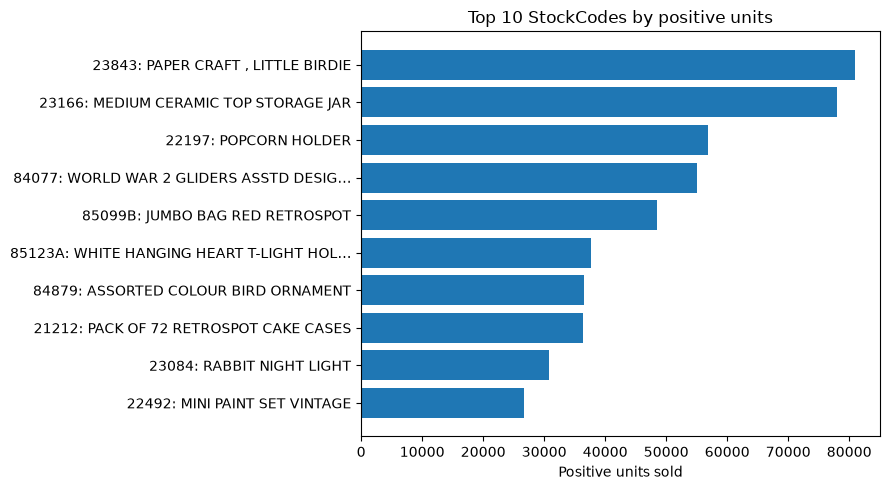

In [5]:
def short_label(row, n=32):
    desc = row["representative_description"]
    desc = "" if pd.isna(desc) else str(desc)
    if len(desc) > n:
        desc = desc[: n - 1] + "…"
    return f"{row['StockCode']}: {desc}"


fig, ax = plt.subplots(figsize=(9, 5))
gplot = top10g.sort_values("gross_merchandise_sales")
ax.barh(range(len(gplot)), gplot["gross_merchandise_sales"])
ax.set_yticks(range(len(gplot)), [short_label(r) for _, r in gplot.iterrows()])
ax.set_xlabel("Gross merchandise sales")
ax.set_title("Top 10 StockCodes by gross merchandise sales")
fig.tight_layout()
p = unique_output_path(FIGURES / "top10_products_gross.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
uplot = top10u.sort_values("positive_units")
ax.barh(range(len(uplot)), uplot["positive_units"])
ax.set_yticks(range(len(uplot)), [short_label(r) for _, r in uplot.iterrows()])
ax.set_xlabel("Positive units sold")
ax.set_title("Top 10 StockCodes by positive units")
fig.tight_layout()
p = unique_output_path(FIGURES / "top10_products_units.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

## 3. Question 8 — Monthly product mix

Each line is dated by its own `InvoiceDate`. December 2011 is kept and flagged as partial.
Trend comments use **complete** months only.

HHI above is a **descriptive** concentration statistic (sum of squared gross-sales shares). It is not a legal or competition-policy finding.

In [6]:
sale_m = sale.groupby(["invoice_month", "StockCode"], dropna=False).agg(
    gross_merchandise_sales=("line_value", "sum"),
    positive_units=("Quantity", "sum"),
)
neg_m = (
    neg.groupby(["invoice_month", "StockCode"], dropna=False)["line_value"]
    .sum()
    .rename("negative_merchandise_value")
)
pm = sale_m.join(neg_m, how="outer").reset_index()
pm["gross_merchandise_sales"] = pm["gross_merchandise_sales"].fillna(0.0)
pm["negative_merchandise_value"] = pm["negative_merchandise_value"].fillna(0.0)
pm["positive_units"] = pm["positive_units"].fillna(0.0)
pm["net_merchandise_value"] = pm["gross_merchandise_sales"] + pm["negative_merchandise_value"]

month_gross = pm.groupby("invoice_month")["gross_merchandise_sales"].transform("sum")
month_units = pm.groupby("invoice_month")["positive_units"].transform("sum")
pm["gross_share_within_month"] = np.where(
    month_gross > 0, pm["gross_merchandise_sales"] / month_gross, pd.NA
)
pm["units_share_within_month"] = np.where(
    month_units > 0, pm["positive_units"] / month_units, pd.NA
)
pm["monthly_gross_sales_rank"] = pm.groupby("invoice_month")["gross_merchandise_sales"].rank(
    method="min", ascending=False
)
pm["is_partial_final_month"] = pm["invoice_month"] == partial_month

assert penny_sum(pm["gross_merchandise_sales"]) == NB01_GROSS
assert penny_sum(pm["negative_merchandise_value"]) == NB01_NEG
assert penny_sum(pm["net_merchandise_value"]) == NB01_NET

share_check = (
    pm.loc[month_gross > 0]
    .groupby("invoice_month")["gross_share_within_month"]
    .sum()
)
assert ((share_check - 1).abs() < 1e-9).all()
print("Product-month rows:", len(pm))
print("Months:", pm["invoice_month"].nunique())

Product-month rows: 34137
Months: 13


mix_series       22423     23843   85123A    47566   85099B    23166    23084    22086   84879    79321  Other products
invoice_month                                                                                                          
2010-12        27870.0       0.0  10435.0   1208.0   4019.0      0.0      0.0   9226.0  3986.0   7506.0        713761.0
2011-01        12801.0       0.0  15223.0   2288.0   5048.0  77184.0      0.0    143.0  2921.0   5901.0        550484.0
2011-02        11009.0       0.0   5140.0   4348.0   5617.0      0.0      0.0     25.0  2736.0   3616.0        476461.0
2011-03        18372.0       0.0   5598.0   9123.0  10118.0      0.0      0.0    232.0  4303.0   3093.0        640427.0
2011-04        14813.0       0.0  10018.0  10778.0   4878.0      0.0      0.0     44.0  4174.0    358.0        471247.0
2011-05        12646.0       0.0  11216.0  19148.0   7123.0    891.0   2280.0     65.0  5052.0   2297.0        680558.0
2011-06         9745.0       0.0   4681.

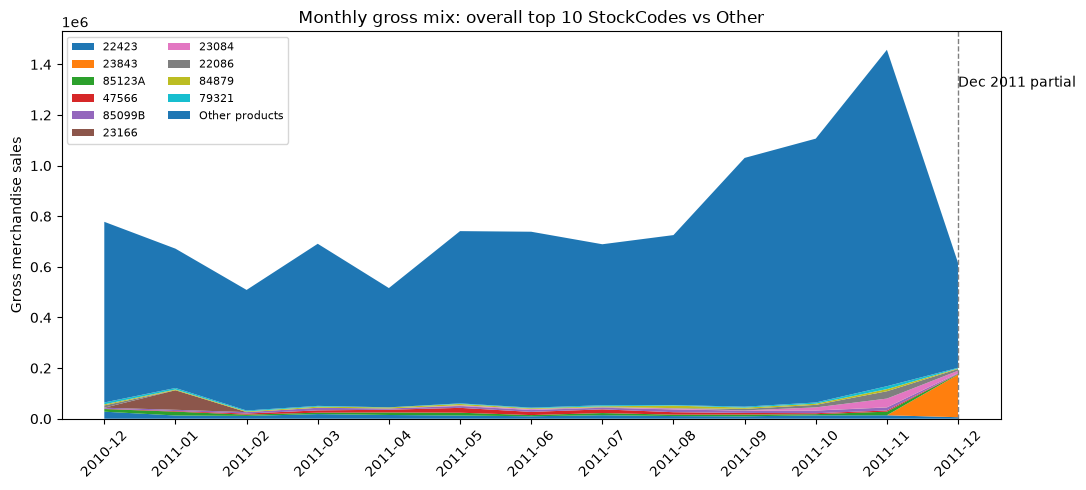

In [7]:
top10_codes = set(top10g["StockCode"].astype(str))
pm["mix_series"] = np.where(
    pm["StockCode"].astype(str).isin(top10_codes),
    pm["StockCode"].astype(str),
    "Other products",
)
mix_pivot = pm.pivot_table(
    index="invoice_month",
    columns="mix_series",
    values="gross_merchandise_sales",
    aggfunc="sum",
    fill_value=0.0,
)
# Stable column order: overall top 10 then Other.
ordered = [str(c) for c in top10g["StockCode"]] + ["Other products"]
ordered = [c for c in ordered if c in mix_pivot.columns]
mix_pivot = mix_pivot[ordered]
print(mix_pivot.round(0).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x = mix_pivot.index.astype(str)
ax.stackplot(x, [mix_pivot[c].to_numpy() for c in mix_pivot.columns], labels=mix_pivot.columns)
ax.set_ylabel("Gross merchandise sales")
ax.set_title("Monthly gross mix: overall top 10 StockCodes vs Other")
ax.legend(loc="upper left", fontsize=8, ncol=2)
if str(partial_month) in list(x):
    ax.axvline(list(x).index(str(partial_month)), color="gray", linestyle="--", linewidth=1)
    ax.annotate("Dec 2011 partial", xy=(list(x).index(str(partial_month)), mix_pivot.sum(axis=1).max() * 0.9))
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
p = unique_output_path(FIGURES / "monthly_product_mix_top10.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

## 4. Question 8 — Early vs late complete three-month periods

- **Early:** 2011-01-01 inclusive to 2011-04-01 exclusive (Jan–Mar 2011, complete).
- **Late:** 2011-09-01 inclusive to 2011-12-01 exclusive (Sep–Nov 2011, complete).

Products seen only in one period are **first/last observed in these comparison periods**, not confirmed new or discontinued SKUs.
No percentage-growth is calculated when early-period sales are zero.

In [8]:
EARLY_START, EARLY_END = pd.Timestamp("2011-01-01"), pd.Timestamp("2011-04-01")
LATE_START, LATE_END = pd.Timestamp("2011-09-01"), pd.Timestamp("2011-12-01")

early_mask = (sale["InvoiceDate"] >= EARLY_START) & (sale["InvoiceDate"] < EARLY_END)
late_mask = (sale["InvoiceDate"] >= LATE_START) & (sale["InvoiceDate"] < LATE_END)

def period_stats(mask, prefix):
    g = sale.loc[mask].groupby("StockCode", dropna=False).agg(
        **{
            f"{prefix}_gross": ("line_value", "sum"),
            f"{prefix}_units": ("Quantity", "sum"),
        }
    )
    return g

period = period_stats(early_mask, "early").join(period_stats(late_mask, "late"), how="outer")
period = period.fillna(0.0).reset_index()
early_total = float(period["early_gross"].sum())
late_total = float(period["late_gross"].sum())
period["early_share"] = period["early_gross"] / early_total if early_total else pd.NA
period["late_share"] = period["late_gross"] / late_total if late_total else pd.NA
period["gross_sales_change"] = period["late_gross"] - period["early_gross"]
period["share_change_pp"] = (period["late_share"] - period["early_share"]) * 100
period["early_rank"] = period["early_gross"].rank(method="min", ascending=False)
period["late_rank"] = period["late_gross"].rank(method="min", ascending=False)
period["rank_change"] = period["early_rank"] - period["late_rank"]  # positive = improved
period = period.merge(
    product[["StockCode", "representative_description"]], on="StockCode", how="left"
)

assert abs(float(period["early_share"].sum()) - 1) < 1e-9
assert abs(float(period["late_share"].sum()) - 1) < 1e-9
print("Early gross:", penny(early_total), "Late gross:", penny(late_total))

gainers = period.sort_values(["share_change_pp", "StockCode"], ascending=[False, True]).head(10)
decliners = period.sort_values(["share_change_pp", "StockCode"], ascending=[True, True]).head(10)
only_late = period.loc[(period["early_gross"] == 0) & (period["late_gross"] > 0)].sort_values(
    "late_gross", ascending=False
)
only_early = period.loc[(period["late_gross"] == 0) & (period["early_gross"] > 0)].sort_values(
    "early_gross", ascending=False
)
print("StockCodes only in late period:", len(only_late), "only in early period:", len(only_early))
print("\nLargest share gainers (percentage points):")
print(gainers[["StockCode", "representative_description", "early_share", "late_share",
               "share_change_pp", "early_gross", "late_gross"]].head(5).to_string(index=False))
print("\nLargest share decliners (percentage points):")
print(decliners[["StockCode", "representative_description", "early_share", "late_share",
                 "share_change_pp", "early_gross", "late_gross"]].head(5).to_string(index=False))
print("\nLargest late-only (first observed in these periods):")
print(only_late[["StockCode", "representative_description", "late_gross", "late_share"]].head(5).to_string(index=False))
print("\nLargest early-only (last observed in these periods):")
print(only_early[["StockCode", "representative_description", "early_gross", "early_share"]].head(5).to_string(index=False))

Early gross: 1872211.22 Late gross: 3594932.38
StockCodes only in late period: 747 only in early period: 486

Largest share gainers (percentage points):
StockCode        representative_description  early_share  late_share  share_change_pp  early_gross  late_gross
    23084                RABBIT NIGHT LIGHT     0.000000    0.013217         1.321676         0.00    47513.37
    22086    PAPER CHAIN KIT 50'S CHRISTMAS     0.000214    0.012524         1.231009       400.28    45022.53
    23355        HOT WATER BOTTLE KEEP CALM     0.000000    0.006752         0.675238         0.00    24274.35
    22910 PAPER CHAIN KIT VINTAGE CHRISTMAS     0.000121    0.006196         0.607451       227.31    22273.92
    23284     DOORMAT KEEP CALM AND COME IN     0.000000    0.006007         0.600735         0.00    21596.01

Largest share decliners (percentage points):
StockCode         representative_description  early_share  late_share  share_change_pp  early_gross  late_gross
    23166     MEDIUM CE

## 5. Question 9 — Reconcile negative merchandise value

`negative_value_impact_pct` = |signed negative merchandise value| / gross merchandise sales.
This is **not** a confirmed refund rate.

In [9]:
gross_v = float(df.loc[mask_sale, "line_value"].sum())
neg_v = float(df.loc[mask_neg, "line_value"].sum())
net_v = gross_v + neg_v
impact_pct = abs(neg_v) / gross_v * 100 if gross_v else float("nan")
assert penny(gross_v) == NB01_GROSS
assert penny(neg_v) == NB01_NEG
assert penny(net_v) == NB01_NET
print("Gross:", penny(gross_v))
print("Signed negative:", penny(neg_v))
print("Net:", penny(net_v))
print("Negative-value impact %:", impact_pct)

Gross: 10272121.42
Signed negative: -478724.18
Net: 9793397.24
Negative-value impact %: 4.660421740421633


## 6. Question 9 — Split cancellation-related behaviour

Groups are counted **within merchandise candidates**. Non-C negative lines are not assumed to be data errors or cash refunds.
Share of total negative merchandise value uses the signed `mask_neg` total as the denominator.

In [10]:
def group_stats(mask, name):
    sub = df.loc[mask]
    signed = float(sub["line_value"].sum()) if len(sub) else 0.0
    return {
        "group": name,
        "lines": int(mask.sum()),
        "distinct_invoices": int(sub["InvoiceNo"].nunique()) if len(sub) else 0,
        "distinct_identified_customers": int(sub["CustomerID"].nunique()) if len(sub) else 0,
        "signed_line_value": signed,
        "absolute_value": abs(signed),
        "share_of_neg_merchandise_pct": (signed / neg_v * 100) if neg_v else pd.NA,
    }

c_neg = is_merch & df["is_c_prefix_invoice"] & (df["Quantity"] < 0) & (df["UnitPrice"] > 0)
nonc_neg = is_merch & ~df["is_c_prefix_invoice"] & (df["Quantity"] < 0) & (df["UnitPrice"] > 0)
c_not_neg = is_merch & df["is_c_prefix_invoice"] & ~(df["Quantity"] < 0)
neg_qty_not_c = is_merch & (df["Quantity"] < 0) & ~df["is_c_prefix_invoice"]
zero_price = is_merch & (df["UnitPrice"] == 0)

neg_types = pd.DataFrame(
    [
        group_stats(c_neg, "C_prefix_negative_qty_positive_price"),
        group_stats(nonc_neg, "nonC_negative_qty_positive_price"),
        group_stats(c_not_neg, "C_prefix_not_negative_qty"),
        group_stats(neg_qty_not_c, "negative_qty_not_C_any_price"),
        group_stats(zero_price, "zero_price_merchandise"),
    ]
)
assert penny(float(df.loc[c_neg, "line_value"].sum()) + float(df.loc[nonc_neg, "line_value"].sum())) == NB01_NEG
print(neg_types.to_string(index=False))
print("C-prefix merchandise lines that are not negative qty:", int(c_not_neg.sum()))

                               group  lines  distinct_invoices  distinct_identified_customers  signed_line_value  absolute_value  share_of_neg_merchandise_pct
C_prefix_negative_qty_positive_price   8704               3422                           1534         -478724.18       478724.18                         100.0
    nonC_negative_qty_positive_price      0                  0                              0               0.00            0.00                          -0.0
           C_prefix_not_negative_qty      0                  0                              0               0.00            0.00                          -0.0
        negative_qty_not_C_any_price   1336               1336                              0               0.00            0.00                          -0.0
              zero_price_merchandise   2501               2143                             25               0.00            0.00                          -0.0
C-prefix merchandise lines that are not negati

## 7. Question 9 — Monthly impact

December 2011 is marked partial. Do not treat its negative/gross ratio as a comparable full-month rate.

In [11]:
monthly = pd.DataFrame(
    {
        "gross_merchandise_sales": sale.groupby("invoice_month")["line_value"].sum(),
        "c_prefix_negative_value": df.loc[c_neg].groupby("invoice_month")["line_value"].sum(),
        "nonc_negative_value": df.loc[nonc_neg].groupby("invoice_month")["line_value"].sum(),
        "positive_sale_invoices": sale.groupby("invoice_month")["InvoiceNo"].nunique(),
        "c_prefix_invoices": df.loc[c_neg].groupby("invoice_month")["InvoiceNo"].nunique(),
    }
).fillna(
    {
        "gross_merchandise_sales": 0.0,
        "c_prefix_negative_value": 0.0,
        "nonc_negative_value": 0.0,
        "positive_sale_invoices": 0,
        "c_prefix_invoices": 0,
    }
)
monthly["total_signed_negative"] = (
    monthly["c_prefix_negative_value"] + monthly["nonc_negative_value"]
)
monthly["net_merchandise_value"] = (
    monthly["gross_merchandise_sales"] + monthly["total_signed_negative"]
)
den = monthly["gross_merchandise_sales"].replace(0, pd.NA)
monthly["abs_negative_pct_of_gross"] = monthly["total_signed_negative"].abs() / den * 100
monthly["is_partial_final_month"] = monthly.index == partial_month
monthly = monthly.sort_index().reset_index().rename(columns={"invoice_month": "month"})
monthly["month"] = monthly["month"].astype(str)

assert penny_sum(monthly["gross_merchandise_sales"]) == NB01_GROSS
assert penny_sum(monthly["total_signed_negative"]) == NB01_NEG
print(monthly.to_string(index=False))

  month  gross_merchandise_sales  c_prefix_negative_value  nonc_negative_value  positive_sale_invoices  c_prefix_invoices  total_signed_negative  net_merchandise_value  abs_negative_pct_of_gross  is_partial_final_month
2010-12               778010.910                -17607.86                  0.0                    1550                301              -17607.86             760403.050                   2.263189                   False
2011-01               671992.410                -91526.30                  0.0                    1081                247              -91526.30             580466.110                  13.620139                   False
2011-02               508952.870                 -8375.87                  0.0                    1093                191               -8375.87             500577.000                   1.645706                   False
2011-03               691265.940                -10675.30                  0.0                    1440                281   

Saved D:\Python Projects\retail-transaction-analytics\outputs\figures\monthly_negative_value_impact.png


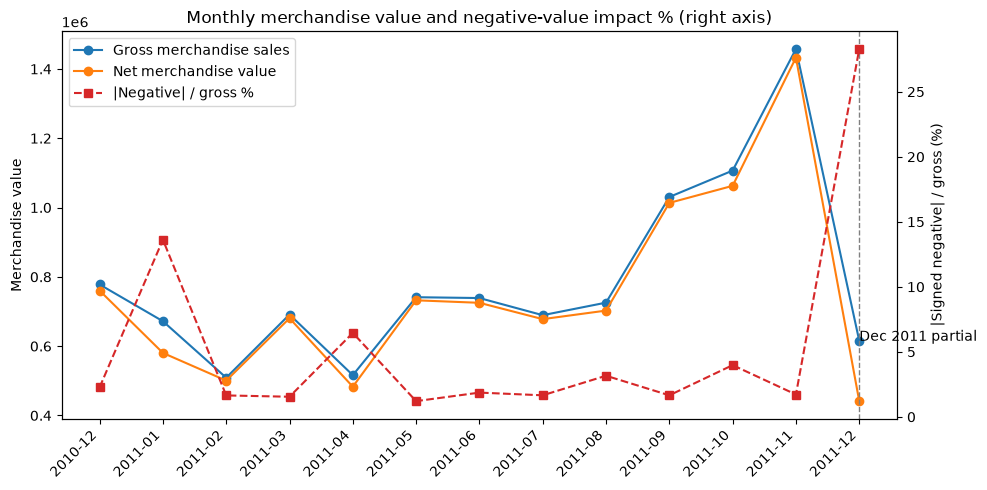

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(monthly))
ax1.plot(x, monthly["gross_merchandise_sales"], marker="o", label="Gross merchandise sales")
ax1.plot(x, monthly["net_merchandise_value"], marker="o", label="Net merchandise value")
ax1.set_ylabel("Merchandise value")
ax1.set_xticks(x, monthly["month"], rotation=45, ha="right")
ax2 = ax1.twinx()
ax2.plot(
    x,
    monthly["abs_negative_pct_of_gross"],
    color="tab:red",
    marker="s",
    linestyle="--",
    label="|Negative| / gross %",
)
ax2.set_ylabel("|Signed negative| / gross (%)")
if monthly["is_partial_final_month"].any():
    i = int(monthly.index[monthly["is_partial_final_month"]][0])
    ax1.axvline(i, color="gray", linestyle="--", linewidth=1)
    ax1.annotate("Dec 2011 partial", xy=(i, monthly.loc[i, "gross_merchandise_sales"]))
# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")
ax1.set_title("Monthly merchandise value and negative-value impact % (right axis)")
fig.tight_layout()
p = unique_output_path(FIGURES / "monthly_negative_value_impact.png")
fig.savefig(p, dpi=120)
print("Saved", p)
plt.show()

## 8. Question 9 — Product and customer impact

A customer with high negative merchandise value is **not** a confirmed churned customer and **not** a confirmed refund customer. Only high negative activity is observable here.

In [13]:
top_neg_prod = product.assign(
    abs_negative=lambda d: d["negative_merchandise_value"].abs()
).sort_values(["abs_negative", "StockCode"], ascending=[False, True]).head(20)
top_neg_prod["neg_pct_of_gross"] = np.where(
    top_neg_prod["gross_merchandise_sales"] > 0,
    top_neg_prod["abs_negative"] / top_neg_prod["gross_merchandise_sales"] * 100,
    pd.NA,
)
print("Top 20 StockCodes by |negative merchandise value|:")
print(top_neg_prod[["StockCode", "representative_description", "gross_merchandise_sales",
                    "negative_merchandise_value", "net_merchandise_value",
                    "neg_pct_of_gross"]].to_string(index=False))

id_sale = sale.loc[sale["CustomerID"].notna()]
id_neg = neg.loc[neg["CustomerID"].notna()]
cg = id_sale.groupby("CustomerID")["line_value"].sum().rename("gross_merchandise_sales")
cn = id_neg.groupby("CustomerID")["line_value"].sum().rename("negative_merchandise_value")
cust_neg = pd.concat([cg, cn], axis=1).fillna(0.0)
cust_neg["net_merchandise_value"] = (
    cust_neg["gross_merchandise_sales"] + cust_neg["negative_merchandise_value"]
)
cust_neg["abs_negative"] = cust_neg["negative_merchandise_value"].abs()
top_neg_cust = (
    cust_neg.sort_values(["abs_negative", "CustomerID"], ascending=[False, True])
    .head(20)
    .reset_index()
)
print("\nTop 20 identified customers by |negative merchandise value|:")
print(top_neg_cust.to_string(index=False))

Top 20 StockCodes by |negative merchandise value|:
StockCode         representative_description  gross_merchandise_sales  negative_merchandise_value  net_merchandise_value neg_pct_of_gross
    23843        PAPER CRAFT , LITTLE BIRDIE                168469.60                  -168469.60                   0.00            100.0
    23166     MEDIUM CERAMIC TOP STORAGE JAR                 81700.92                   -77479.64                4221.28        94.833253
    22423           REGENCY CAKESTAND 3 TIER                174484.74                    -9722.55              164762.19         5.572149
   85123A WHITE HANGING HEART T-LIGHT HOLDER                104518.80                    -6624.30               97894.50         6.337903
    21108 FAIRY CAKE FLANNEL ASSORTED COLOUR                 18069.28                    -6591.42               11477.86        36.478598
    23113              PANTRY CHOPPING BOARD                  5868.50                    -4803.06                1065.44 


Top 20 identified customers by |negative merchandise value|:
CustomerID  gross_merchandise_sales  negative_merchandise_value  net_merchandise_value  abs_negative
     16446                168472.50                  -168469.60           2.900000e+00     168469.60
     12346                 77183.60                   -77183.60           0.000000e+00      77183.60
     15749                 44534.30                   -22998.40           2.153590e+04      22998.40
     16029                 72882.09                   -14688.24           5.819385e+04      14688.24
     12931                 42055.96                    -8511.15           3.354481e+04       8511.15
     14911                136275.72                    -7393.59           1.288821e+05       7393.59
     14607                 15021.50                    -5228.40           9.793100e+03       5228.40
     17450                194550.79                    -4815.26           1.897355e+05       4815.26
     17949                 58

## 9. Optional possible prior-sale match (exploratory)

Match identified negative merchandise lines to an earlier-or-equal positive sale on CustomerID, StockCode, UnitPrice (rounded to 2 decimals), and absolute Quantity.

If several positives qualify, the **closest prior** timestamp is kept (then lowest `raw_row_id`). Multiple candidates are counted as **ambiguous**. This is a **possible prior-sale match**, not confirmed refund linkage.

In [14]:
neg_id = df.loc[mask_neg & df["CustomerID"].notna(), [
    "raw_row_id", "CustomerID", "StockCode", "UnitPrice", "Quantity", "InvoiceDate"
]].copy()
pos_id = df.loc[mask_sale & df["CustomerID"].notna(), [
    "raw_row_id", "CustomerID", "StockCode", "UnitPrice", "Quantity", "InvoiceDate"
]].copy()
neg_id["qty_abs"] = neg_id["Quantity"].abs()
neg_id["price_2dp"] = neg_id["UnitPrice"].round(2)
pos_id["price_2dp"] = pos_id["UnitPrice"].round(2)

keys = ["CustomerID", "StockCode", "price_2dp"]
cand = neg_id.merge(pos_id, on=keys, suffixes=("_neg", "_pos"))
cand = cand[cand["Quantity_pos"] == cand["qty_abs"]]
cand = cand[cand["InvoiceDate_pos"] <= cand["InvoiceDate_neg"]]

n_neg = len(neg_id)
n_with_any = cand["raw_row_id_neg"].nunique() if len(cand) else 0
counts = cand.groupby("raw_row_id_neg").size() if len(cand) else pd.Series(dtype=int)
n_unique = int((counts == 1).sum()) if len(counts) else 0
n_ambiguous = int((counts > 1).sum()) if len(counts) else 0
n_unmatched = n_neg - n_with_any

# One deterministic closest-prior row per negative line (for count check only; not exported).
if len(cand):
    cand = cand.sort_values(
        ["raw_row_id_neg", "InvoiceDate_pos", "raw_row_id_pos"],
        ascending=[True, False, True],
    )
    chosen = cand.groupby("raw_row_id_neg", as_index=False).head(1)
else:
    chosen = cand

print("Identified negative merchandise lines:", n_neg)
print("Unmatched (no candidate):", n_unmatched)
print("Exactly one candidate:", n_unique)
print("Ambiguous (2+ candidates; closest prior still selected):", n_ambiguous)
print("Possible matches selected:", len(chosen))
print("Match table is not exported (would be near transaction-level).")

Identified negative merchandise lines: 8539
Unmatched (no candidate): 5766
Exactly one candidate: 2162
Ambiguous (2+ candidates; closest prior still selected): 611
Possible matches selected: 2773
Match table is not exported (would be near transaction-level).


## 10. Duplicate sensitivity

Baseline keeps extras. Sensitivity uses the same merchandise masks after dropping exact duplicate extras (lowest `raw_row_id` retained).

In [15]:
g_keep = float(df.loc[mask_sale & keep, "line_value"].sum())
n_keep = float(df.loc[mask_neg & keep, "line_value"].sum())
net_keep = g_keep + n_keep
imp_keep = abs(n_keep) / g_keep * 100 if g_keep else float("nan")
print("Baseline gross / neg / net / impact%:", penny(gross_v), penny(neg_v), penny(net_v), impact_pct)
print("No extras gross / neg / net / impact%:", penny(g_keep), penny(n_keep), penny(net_keep), imp_keep)
print("Impact pp difference:", imp_keep - impact_pct)

Baseline gross / neg / net / impact%: 10272121.42 -478724.18 9793397.24 4.660421740421633
No extras gross / neg / net / impact%: 10247907.68 -475901.16 9772006.52 4.643886095787736
Impact pp difference: -0.016535644633896673


## 11. Validation

In [16]:
assert penny_sum(product["gross_merchandise_sales"]) == NB01_GROSS
assert penny_sum(product["negative_merchandise_value"]) == NB01_NEG
assert penny_sum(product["net_merchandise_value"]) == NB01_NET
assert penny_sum(pm["gross_merchandise_sales"]) == NB01_GROSS
assert penny_sum(pm["negative_merchandise_value"]) == NB01_NEG
assert penny_sum(monthly["gross_merchandise_sales"]) == NB01_GROSS
assert penny_sum(monthly["total_signed_negative"]) == NB01_NEG
assert penny(
    float(df.loc[c_neg, "line_value"].sum() + df.loc[nonc_neg, "line_value"].sum())
) == NB01_NEG
assert ((share_check - 1).abs() < 1e-9).all()
assert abs(float(period["early_share"].sum()) - 1) < 1e-9
assert abs(float(period["late_share"].sum()) - 1) < 1e-9
assert monthly.loc[monthly["is_partial_final_month"], "month"].tolist() == [str(partial_month)]
print("All product-mix and negative-value assertions passed.")

All product-mix and negative-value assertions passed.


## 12. Save tables (non-overwriting)

In [17]:
pm_out = pm.copy()
pm_out["invoice_month"] = pm_out["invoice_month"].astype(str)

files = {
    "product_summary.csv": product,
    "product_monthly_mix.csv": pm_out,
    "product_period_comparison.csv": period,
    "monthly_negative_value_impact.csv": monthly,
    "negative_value_by_type.csv": neg_types,
    "top_negative_value_products.csv": top_neg_prod,
    "top_negative_value_customers.csv": top_neg_cust,
}
for name, frame in files.items():
    out = unique_output_path(TABLES / name)
    frame.to_csv(out, index=False)
    print("Saved", out)

Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\product_summary.csv


Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\product_monthly_mix.csv


Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\product_period_comparison.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\monthly_negative_value_impact.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\negative_value_by_type.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\top_negative_value_products.csv
Saved D:\Python Projects\retail-transaction-analytics\outputs\tables\top_negative_value_customers.csv


## 13. Findings

Figures are from this executed notebook. Merchandise totals reconcile to gross **10,272,121.42**, signed negative **−478,724.18**, net **9,793,397.24**. Duplicate extras remain in the baseline. Description is supporting text; the product key is **StockCode**.

### Question 8 — Product mix

- **3,928** merchandise StockCodes (**14** with no positive sales). Gross sales are not concentrated: HHI = **0.00212** (sum of squared shares on a 0–1 scale; descriptive only). Top **10** StockCodes are **9.43%** of gross; top **20** are **13.52%**.
- Highest gross: **22423** REGENCY CAKESTAND 3 TIER (**174,484.74**), **23843** PAPER CRAFT , LITTLE BIRDIE (**168,469.60**), **85123A** WHITE HANGING HEART T-LIGHT HOLDER (**104,518.80**). Highest units: **23843** (**80,995**), **23166** MEDIUM CERAMIC TOP STORAGE JAR (**78,033**), **22197** POPCORN HOLDER (**56,921**). **23843**’s entire gross appears in **partial December 2011**; it is not a complete-month mix shift.
- Complete Jan–Mar vs Sep–Nov 2011: early gross **1,872,211.22**, late **3,594,932.38**. Largest share gainer: **23084** RABBIT NIGHT LIGHT (**+1.32 pp**; not observed in the early window). Largest share decliner: **23166** (**−4.08 pp**; early **77,183.60**, late **1,502.24**). **747** StockCodes are first observed only in the late window of this comparison; **486** only in the early window — not confirmed launches or discontinuations.

### Question 9 — Negative-value impact

- Overall |negative| / gross is **4.66%**. This is **not** a confirmed refund rate. **All** signed negative merchandise value (**−478,724.18**) sits on **C-prefixed** negative-quantity lines (**8,704** lines, **3,422** invoices, **1,534** identified customers). Non-C merchandise negative-quantity lines: **1,336** lines, **signed value 0** (they fail UnitPrice > 0), **0** identified customers. No C-prefixed merchandise lines with non-negative quantity.
- Among **complete** months, January 2011 has the highest |negative|/gross (**13.62%**). December 2011 is **28.29%** and is **partial** (ends 2011-12-09); that ratio is not a comparable full-month rate. **23843** and customer **16446** account for **168,469.60** of absolute negative value (offsetting the same StockCode’s gross). **12346** has gross **77,183.60** and matching negative **−77,183.60**. High negative activity is not confirmed churn or a confirmed cash refund.
- Duplicate extras change impact from **4.66%** to **4.64%** (−0.017 percentage points). That does not change the conclusion that signed negative merchandise is a modest share of gross except in a few codes/customers and the partial final month.

### Optional possible prior-sale match (implemented)

Identified negative merchandise lines: **8,539**. Unmatched: **5,766**. Exactly one candidate: **2,162**. Ambiguous (2+; closest prior still selected): **611**. Possible matches selected: **2,773**. Not exported. This is **not** confirmed refund linkage.

### Proposed actions (not proven causes)

- Treat **23843** / **16446** and **23166** / **12346** as investigation candidates for large offsetting negatives, not as a general refund rate.
- For mix, watch complete-month movers such as **23084** and Christmas kits (**22086**) without treating Dec 2011 **23843** as a structural mix change.
- Keep non-C zero-price negative-quantity merchandise lines out of the signed merchandise-value total; they are a separate process from C-prefix negatives.

### Limitations

Provisional `merchandise_candidate` map; description drift across one StockCode; duplicate extras in the baseline; partial December 2011; no confirmed refund or return linkage even where a possible prior-sale match exists.
